#### Some texts and explanation here

#### Importing Packages

In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torch.utils.data import TensorDataset
import matplotlib.pyplot as plt
from matplotlib import cm

In [2]:
torch.manual_seed(123) # fixing the seed

#### Setting up the parameters

In [3]:
a_min= 1.0  
a_max= 3.0  
std =  0.3 
N = 256 #  Dimensionality of the state $X \in \mathbb{R}^N$
p = 1.5 # Exponent 

### Setting Up the data and the DataLoader

In [4]:
num_train_points = 10 #number of training points
batch_size  = 10

In [5]:
X_train = torch.empty(num_train_points, N)

In [6]:
for i in range(0, num_train_points):
    a_i = torch.empty(1).uniform_(a_min, a_max)
    X_train[i] = torch.normal(a_i.squeeze(0),std,size=(N,),).abs() #abs: not permitting negative values,This will almost never happen for a_i in reasonable range.  Otherwise use truncated normal

Y_train =(X_train.pow(p).mean(dim=1).pow(1 / p))  # generalized mean  Doing mean over each row

In [7]:
train_data = TensorDataset(X_train, Y_train) # This is the training dataset, one data: row vector X (N elements) then Y (one element)

In [8]:
data_loader = DataLoader(train_data, batch_size=10, shuffle= True)

#### Setting up the Neural Network

Here we use the $\Phi(\text{ReLU})$ structure, for the `moment-based` structure refer to this [code](https://github.com/HighDimensionalEconLab/econ_layers/blob/982f5658064a3f6efcd53d309d154b443cd48ba7/econ_layers/layers.py#L216-L254).

This is an approximation for the underlying function $\hat{f}: \mathbb{R}^N \rightarrow \mathbb{R}$, where $N$ is the dimensionality of input.

The symmetry induces a structure on the design of the neural network:

$\begin{align}
\hat{u}(X) = \rho\big(\frac{1}{N}\sum_{i=1}^N\phi(X_i)\big)
\end{align}$


where $\phi:\mathbb{R}\rightarrow \mathbb{R}^L$ and $\rho:\mathbb{R}^L\rightarrow \mathbb{R}$

Both $\rho$ and $\phi$ are going to be represented with a neural netwrok.


In [9]:
L = 2

In [10]:
class f_hat_NN(nn.Module):
    def __init__(self,
                 dim_hidden = 128,):
        super().__init__()
        
        self.rho = nn.Sequential(
            nn.Linear(L, dim_hidden),
            nn.ReLU(), 
            nn.Linear(dim_hidden, dim_hidden, bias= False),
            nn.ReLU(), 
            nn.Linear(dim_hidden, dim_hidden, bias= False),
            nn.ReLU(), 
            nn.Linear(dim_hidden, 1),
        )
        
        self.phi = nn.Sequential(
            nn.Linear(1, dim_hidden),
            nn.ReLU(), 
            nn.Linear(dim_hidden, dim_hidden, bias=True),
            nn.ReLU(), 
            nn.Linear(dim_hidden, L, bias=True),
        )
        
        
    def forward(self, X):
        num_batches, N = X.shape
        phi_X = torch.stack(
            [torch.mean(self.phi(X[i, :].reshape([N, 1])), 0) for i in range(num_batches)]
        )
        return self.rho(phi_X)

#### Initializing the Neural Network and Defining the Optimizer

In [11]:
f_hat= f_hat_NN()
learning_rate = 0.005
optimizer = torch.optim.Adam(f_hat.parameters(), lr=learning_rate) #Adam Optimizer 


In [12]:
num_epochs = 3001 # step of optimization
print_epoch_frequency = 600 # how often printing the results

### Training Loop (Optimization Process)


In [13]:
for epoch in range(num_epochs):
    for X,Y in data_loader:
        Y = Y.unsqueeze(dim=1)
        
        optimizer.zero_grad() # Resetting the gradients (with respect to NN coefficients)
        loss = F.mse_loss(f_hat(X), Y, reduction="mean")
        loss.backward() # Calculating the gradients (with respect to NN coefficients)
        optimizer.step() # Using the gradients to minimize the loss function
            
    if epoch % print_epoch_frequency == 0:
        print(f"epoch = {epoch}, loss = {loss.detach().numpy():.2e}")

epoch = 0, loss = 3.91e+00
epoch = 600, loss = 2.23e-06
epoch = 1200, loss = 3.22e-07
epoch = 1800, loss = 7.93e-08
epoch = 2400, loss = 3.27e-07
epoch = 3000, loss = 4.34e-07


#### Setting up the test data

In [14]:
num_test_points = 1000 #number of training points
X_test = torch.empty(num_test_points, N)

for i in range(0, num_test_points):
    a_i = torch.empty(1).uniform_(a_min, a_max)
    X_test[i] = torch.normal(a_i.squeeze(0),std,size=(N,),).abs() #abs: not permitting negative values,This will almost never happen for a_i in reasonable range.  Otherwise use truncated normal

Y_test =(X_test.pow(p).mean(dim=1).pow(1 / p)).unsqueeze(dim = 1)  # generalized mean  Doing mean over each row

In [15]:
f_hat_test = f_hat(X_test)

In [16]:
loss = F.mse_loss(f_hat_test, Y_test, reduction="mean")
rel_error = (torch.abs(f_hat_test - Y_test) / torch.abs(Y_test)).detach().squeeze()
abs_error = torch.abs(f_hat_test - Y_test).detach().squeeze()

### Plotting the test results

In [17]:
log_bins_rel = np.logspace(np.log10(min(rel_error.numpy())), np.log10(max(rel_error.numpy())), 40)

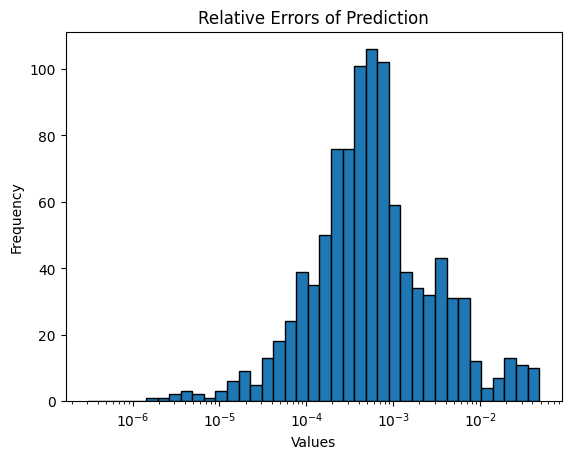

In [18]:
# Plot the histogram
plt.hist(rel_error.numpy(), bins=log_bins_rel, edgecolor='black', density=False)  # Adjust the number of bins as needed
plt.title('Relative Errors of Prediction')
plt.xlabel('Values')
plt.ylabel('Frequency')
plt.xscale('log')

# Show the plot
plt.show()

In [19]:
log_bins_abs = np.logspace(np.log10(min(abs_error.numpy())), np.log10(max(abs_error.numpy())), 40)

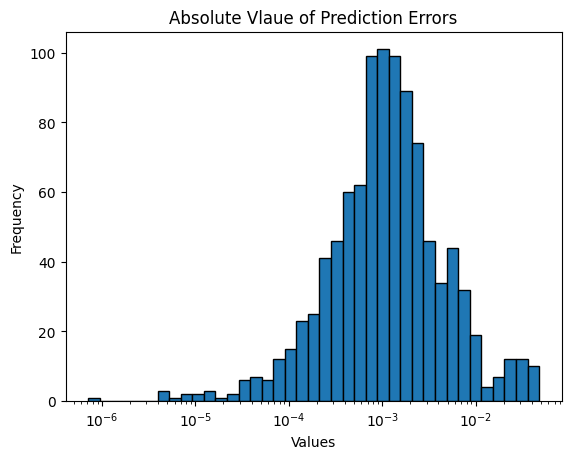

In [20]:
# Plot the histogram
plt.hist(abs_error.numpy(), bins=log_bins_abs, edgecolor='black', density=False)  # Adjust the number of bins as needed
plt.title('Absolute Vlaue of Prediction Errors')
plt.xlabel('Values')
plt.ylabel('Frequency')
plt.xscale('log')

# Show the plot
plt.show()